# Data Exploration — Welltory COVID-19 and Wearables

AIPI 510, Week 4 — Mihir Kosuri

Data: https://github.com/Welltory/hrv-covid19

## Data context and sampling

Welltory is a consumer app that measures heart rate variability (HRV), either through a phone camera or a Bluetooth heart rate monitor. In spring 2020 the company asked users who thought they had COVID-19 to join a research program, and later released the anonymized data on GitHub. It covers 2019-12-31 to 2020-06-19 and 185 participants.

Four things about how it was collected affect everything below.

The participants chose to be in it. They already owned a smartphone, usually a wearable, and were the kind of people who track their own health. This is not a random sample of the population.

Nobody was tested. There are no lab results in the dataset. The `symptoms_onset` date and all the symptom surveys are self-reported, and tests were hard to get in spring 2020, so some of these people probably did not have COVID.

There was no measurement schedule. People measured when they wanted to, so a row exists partly because of how that person was feeling that day.

The devices are mixed. Phone-camera HRV and chest-strap HRV sit in the same table with no column saying which was used, and the wearable fields depend on what gadget someone owned.

The right way to use this data is exploratory. It cannot support a claim that COVID is detectable from a smartwatch.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

In [2]:
# csvs are in week4/, this just looks for them nearby
path = None
for base in [Path.cwd(), *Path.cwd().parents][:4]:
    found = list(base.rglob("participants.csv"))
    if found:
        path = found[0].parent
        break

print("using:", path)

participants = pd.read_csv(path/"participants.csv")
hrv = pd.read_csv(path/"hrv_measurements.csv")
wearables = pd.read_csv(path/"wearables.csv")
sleep = pd.read_csv(path/"sleep.csv")
surveys = pd.read_csv(path/"surveys.csv")
scales = pd.read_csv(path/"scales_description.csv")

for name, df in [("participants", participants), ("hrv", hrv), ("wearables", wearables),
                 ("sleep", sleep), ("surveys", surveys)]:
    print(name, df.shape, df.user_code.nunique(), "users")

using: /home/claude/week4
participants (185, 8) 185 users
hrv (3245, 22) 185 users
wearables (3098, 18) 79 users
sleep (425, 12) 10 users
surveys (2259, 5) 111 users


In [3]:
hrv.head()

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."


## What the features mean

Most of this comes from the `datatypes.md` file in the repo. The HRV metrics needed some outside reading since they are not self-explanatory.

`participants` is one row per person: `user_code` (the key everything joins on), `gender`, `age_range`, `city`, `country`, `height` in cm, `weight` in kg, and `symptoms_onset` as MM/DD/YYYY.

`hrv_measurements` is one row per measurement and is the main table.

| Column | What it is |
|---|---|
| `bpm`, `meanrr` | heart rate, and the average time between heartbeats in ms |
| `sdnn` | standard deviation of the intervals, the general "how much HRV" number |
| `rmssd`, `pnn50` | beat-to-beat variability, which tracks parasympathetic (rest and digest) activity |
| `mxdmn`, `mode`, `amo` | range, most common interval, and how tall that peak is |
| `lf`, `hf`, `vlf`, `total_power`, `lfhf` | power in different frequency bands |
| `how_feel`, `how_mood`, `how_sleep` | self-report right after measuring, on a −2 to +2 scale |
| `rr_data` | the actual intervals between heartbeats, as a comma-separated string |
| `tags` | tags the user picked, semicolon-separated |

The rest: `wearables` is one row per user per day (steps, pulse, calories), `sleep` is one row per sleep session, `surveys` is one row per user, question and date, and `scales_description` translates the survey codes into English.

One piece of background matters more than the rest. HRV is very person-specific. Higher is generally better and it drops with illness, stress and age, but the normal range for one person looks nothing like the normal range for another. An SDNN of 35 can be a red flag for one person and completely fine for someone else. This comes up repeatedly below.

## Questions we are asking:
* What are the dimensions of the dataset (rows and columns)?
* What are the data types of the variables?
* Are there missing values, and how are they represented?

In [4]:
hrv.info()

<class 'pandas.DataFrame'>
RangeIndex: 3245 entries, 0 to 3244
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_code             3245 non-null   str    
 1   rr_code               3245 non-null   str    
 2   measurement_datetime  3245 non-null   str    
 3   time_of_day           3245 non-null   str    
 4   bpm                   3245 non-null   int64  
 5   meanrr                3245 non-null   float64
 6   mxdmn                 3245 non-null   float64
 7   sdnn                  3245 non-null   float64
 8   rmssd                 3245 non-null   float64
 9   pnn50                 3245 non-null   float64
 10  mode                  3245 non-null   float64
 11  amo                   3245 non-null   float64
 12  lf                    3245 non-null   float64
 13  hf                    3245 non-null   float64
 14  vlf                   3245 non-null   float64
 15  lfhf                  3245 non-n

In [5]:
print("missing values in hrv:")
print(hrv.isnull().sum()[hrv.isnull().sum() > 0])

print("\nwhat the date columns actually look like:")
print(participants.symptoms_onset.dropna().iloc[0])
print(hrv.measurement_datetime.iloc[0])
print(wearables.day.iloc[0])

print("\nduplicated keys:")
print("hrv     ", hrv.duplicated(["user_code", "measurement_datetime"]).sum())
print("sleep   ", sleep.duplicated(["user_code", "day"]).sum())
print("surveys ", surveys.duplicated(["user_code", "scale", "created_at"]).sum())

missing values in hrv:
how_sleep    1779
tags         1044
dtype: int64

what the date columns actually look like:
5/15/2020
2020-04-21 21:23:08
2020-04-26

duplicated keys:
hrv      0
sleep    38
surveys  24


## Interpretation

There are 3,245 HRV measurements with 22 columns, from 185 people. `participants` works as a lookup table and every other table joins onto it with `user_code`.

Only two columns in the HRV table have missing values: `how_sleep` at 55% and `tags` at 32%. Both are optional things a user can skip. Every actual measurement column is complete.

All of the date columns loaded as strings. The formats are inconsistent across files, which is probably why pandas did not guess them. Leaving them as strings would break sorting, since "12/01" sorts before "2/01" as text.

`sleep` and `surveys` have repeated keys, 38 and 24. Those get looked at in the duplicates section, and one of them turns out not to be what it looks like.

## Questions we are asking:
* What are the central tendency measures for the numerical variables?
* What are the measures of dispersion?
* What is the distribution of the variables (normal, skewed)?

In [6]:
metrics = ["bpm", "meanrr", "sdnn", "rmssd", "pnn50", "lf", "hf", "vlf", "total_power"]
hrv[metrics].describe().round(1)

,bpm,meanrr,sdnn,rmssd,pnn50,lf,hf,vlf,total_power
count,3245.0,3245.0,3245.0,3245.0,3245.0,3245.0,3245.0,3245.0,3245.0
mean,73.3,839.6,52.5,52.8,20.6,927.0,1125.0,578.2,2630.3
std,12.2,137.4,29.4,39.4,18.6,1455.4,2490.5,876.7,3912.2
min,44.0,477.7,9.5,6.3,0.0,2.0,4.0,1.0,44.0
25%,65.0,742.5,32.6,29.0,6.1,151.0,158.0,116.0,620.0
50%,72.0,829.1,46.9,42.9,16.2,423.0,380.0,293.0,1387.0
75%,81.0,925.9,64.4,62.5,29.3,1059.0,993.0,693.0,2906.0
max,125.0,1346.7,206.6,310.8,91.9,15522.0,33490.0,18468.0,41118.0


In [7]:
print("skew and kurtosis:")
print(pd.DataFrame({"skew": hrv[metrics].skew(), "kurtosis": hrv[metrics].kurt()}).round(2))

print("\nwho's in the study:")
print(participants.gender.value_counts())
print(participants.age_range.value_counts().sort_index())
print(participants.country.value_counts().head(5))

skew and kurtosis:
             skew  kurtosis
bpm          0.48      0.05
meanrr       0.33     -0.15
sdnn         1.72      4.17
rmssd        2.66      9.04
pnn50        1.41      2.02
lf           3.80     19.73
hf           5.34     36.00
vlf          6.05     76.79
total_power  3.79     18.24

who's in the study:
gender
f    118
m     67
Name: count, dtype: int64
age_range
18-24    16
25-34    46
35-44    56
45-54    51
55-64     9
65-74     7
Name: count, dtype: int64
country
Russia            66
United States     60
United Kingdom    12
Ukraine            7
Brazil             6
Name: count, dtype: int64


## Interpretation

Mean heart rate is 73 bpm and median SDNN is 47 ms. Those are normal numbers for a mix of adults, which suggests the app's measurements are not broken in any obvious way.

The spread is very wide. SDNN runs from about 10 to 207. In most datasets that would look like corruption, but HRV really does vary that much between people. A fit, relaxed 25-year-old and a stressed 60-year-old can sit at opposite ends of that range. Most of the variance here is between people rather than within them.

The frequency columns are badly skewed. `hf` has a skew of 5.3 and `vlf` is 6.1, with kurtosis in the 30s and 70s. The min and max explain why: `hf` runs from 4 to 33,490. Spectral power cannot go below zero but has no real ceiling, so it piles up near zero with a long tail. These need a log transform before they can be correlated with anything. `bpm` and `meanrr` are close to symmetric and can be used as they are.

The cohort itself is 118 women and 67 men, mostly aged 25 to 54, and Russia and the US together account for 126 of the 185 people. With the self-selection described earlier, any result here applies to health-app users in those two countries in 2020 and not much further.

## Questions we are asking:
* How complete is the data, and is what's missing random?
* Are the values accurate, and can they be checked against the raw signal?
* Do the units and formats match the documentation?
* Do all the keys resolve?

In [8]:
# worst columns in each table
print("wearables % missing:")
print((wearables.isnull().mean() * 100).sort_values(ascending=False).head(5).round(1))

print("\nsleep % missing:")
print((sleep.isnull().mean() * 100).sort_values(ascending=False).head(5).round(1))

print("\nhow many of the 185 participants show up in each table:")
for name, df in [("hrv", hrv), ("wearables", wearables), ("sleep", sleep), ("surveys", surveys)]:
    print(name, df.user_code.nunique())

counts = hrv.groupby("user_code").size()
print("\nmeasurements per person:")
print(counts.describe().round(1))
print("people with just 1:", (counts == 1).sum())
print("top 10 users are", round(counts.nlargest(10).sum() / counts.sum() * 100), "% of all rows")

wearables % missing:
average_spo2_value              98.7
body_temperature_avg            97.9
average_environment_exposure    95.2
average_headphone_exposure      92.6
stand_hours_total               82.9
dtype: float64

sleep % missing:
sleep_rem_duration      98.4
sleep_awake_duration    97.9
sleep_deep_duration     96.7
pulse_min               96.5
pulse_max               96.5
dtype: float64

how many of the 185 participants show up in each table:
hrv 185
wearables 79
sleep 10
surveys 111

measurements per person:
count    185.0
mean      17.5
std       45.8
min        1.0
25%        1.0
50%        4.0
75%       12.0
max      405.0
dtype: float64
people with just 1: 54
top 10 users are 54 % of all rows


In [9]:
# rr_data has the raw intervals, so the app's math can be checked against it
sample = hrv.sample(300, random_state=1)
intervals = sample.rr_data.apply(lambda x: np.array(x.split(","), dtype=float))

print("mean of rr_data vs meanrr, biggest gap:",
      round((intervals.apply(np.mean) - sample.meanrr).abs().max(), 4))
print("std of rr_data vs sdnn, biggest gap:   ",
      round((intervals.apply(lambda a: a.std(ddof=1)) - sample.sdnn).abs().max(), 4))
print("lf+hf+vlf vs total_power, biggest gap: ",
      round((hrv.lf + hrv.hf + hrv.vlf - hrv.total_power).abs().max(), 4))

mean of rr_data vs meanrr, biggest gap: 0.0003
std of rr_data vs sdnn, biggest gap:    0.0005
lf+hf+vlf vs total_power, biggest gap:  0.0


In [10]:
print("heights:")
print(participants.height.describe().round(1))
print("\nthe two weird ones:")
print(participants.nlargest(2, "height")[["user_code", "height", "weight"]])

# onset dates
onset = pd.to_datetime(participants.symptoms_onset, format="%m/%d/%Y", errors="coerce")
print("\nonset dates that parsed:", onset.notnull().sum(), "out of", participants.symptoms_onset.notnull().sum())
print("earliest:", onset.min().date(), " latest:", onset.max().date())

bad = onset[(onset < "2019-12-01") | (onset > "2020-06-30")]
print("\noutside the study window:", len(bad))
print(sorted(bad.dt.year))

heights:
count    183.0
mean     170.0
std       12.4
min      132.1
25%      163.5
50%      168.0
75%      174.5
max      250.0
Name: height, dtype: float64

the two weird ones:
      user_code  height   weight
102  83161408c1  250.00   82.146
49   3fff7627ca  248.92  114.713

onset dates that parsed: 147 out of 147
earliest: 1967-01-30  latest: 2022-04-21

outside the study window: 13
[1967, 1968, 1975, 1977, 1981, 1982, 1984, 1987, 1993, 1999, 2000, 2021, 2022]


In [11]:
# the docs say sleep_duration is in hours
print("sleep_duration median:", sleep.sleep_duration.median())
print("that many hours =", round(sleep.sleep_duration.median() / 24 / 365, 1), "years")
print("as seconds =", round(sleep.sleep_duration.median() / 3600, 1), "hours")

# docs say mode is in ms
print("\nmode median:", hrv["mode"].median(), " meanrr median:", hrv.meanrr.median())
print("if mode were ms that's", round(60000 / hrv["mode"].median()), "bpm")

# mxdmn is the range, sdnn is the std dev of the same intervals
print("\nmxdmn median:", hrv.mxdmn.median(), " sdnn median:", round(hrv.sdnn.median(), 1))

sleep_duration median: 26041.0
that many hours = 3.0 years
as seconds = 7.2 hours

mode median: 0.825  meanrr median: 829.1
if mode were ms that's 72727 bpm

mxdmn median: 0.16  sdnn median: 46.9


In [12]:
ids = set(participants.user_code)

for name, df in [("hrv", hrv), ("wearables", wearables), ("sleep", sleep), ("surveys", surveys)]:
    print(name, "users not in participants:", len(set(df.user_code) - ids))

print("\nduplicate user_code in participants:", participants.user_code.duplicated().sum())
print("survey codes not in the lookup table:", len(set(surveys.scale) - set(scales.Scale)))

hrv users not in participants: 0
wearables users not in participants: 0
sleep users not in participants: 0
surveys users not in participants: 0

duplicate user_code in participants: 0
survey codes not in the lookup table: 0


## Interpretation

Completeness is the weakest part of this dataset. Eleven columns are more than 90% empty. SpO2 has 40 real values out of 3,098 rows and `sleep_rem_duration` has seven. Those are the most useful columns for a respiratory illness, which makes it worse. But the gaps are not random: almost no consumer wearable measured blood oxygen or temperature in early 2020, so whether a value exists depends on which device the person owned.

Coverage across tables is uneven too. All 185 people have HRV data, but only 79 have wearables and 10 have sleep. Anything involving sleep is really a study of ten people.

The measurement counts are the most extreme part. The median person has 4 measurements and the maximum is 405. Fifty-four people have exactly one. The ten most active users account for 54% of all rows, so any statistic computed across all rows mostly describes a handful of enthusiasts.

Accuracy splits into two groups. The computed columns hold up. Rebuilding `meanrr` and `sdnn` from the raw `rr_data` matches to about 0.0005, which is float rounding, and `total_power` equals `lf + hf + vlf` exactly. Whatever the app calculated can be trusted.

The typed-in columns do not hold up. Thirteen of the 147 `symptoms_onset` values fall outside the study window, with years like 1967, 1968, 1975 and 1981. Those are birthdays. People typed their date of birth into the symptom onset field. Two more are 2021 and 2022, which look like year typos. The awkward part is that all 147 parse fine as MM/DD/YYYY, so a format check finds nothing. The only way to catch these is to check whether the date makes sense for the study period.

Consistency is poor. The documentation is wrong twice. `sleep_duration` is in seconds, not hours, since a median of 26,041 hours would be three years. `mode` is in seconds, not milliseconds, since 0.825 ms between heartbeats would be 72,000 bpm. There is also `mxdmn` stored in seconds inside a table where everything else is in milliseconds. The docs get that last one right, but it is still easy to trip over.

Integrity is the one clean part. No user codes appear that are missing from `participants`, `user_code` is not duplicated there, and every survey code resolves against the lookup table. The joins are safe even though the data behind them is patchy.

## Questions we are asking:
* Is there correlation between pairs of numerical variables?
* Are any of them redundant?
* How do the self-report columns relate to the physiological ones?

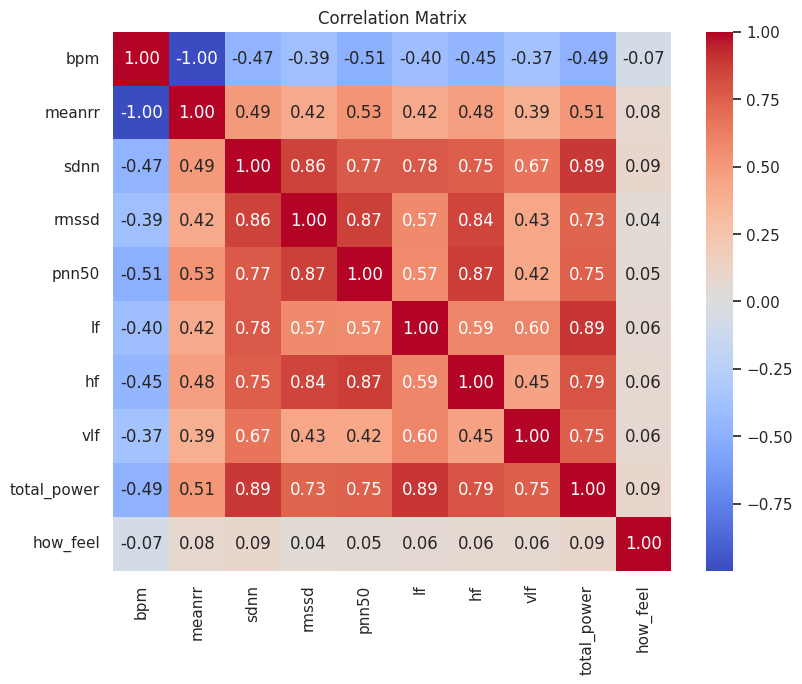

          median  count
how_feel               
-2          36.9    124
-1          45.0    857
 0          48.8   1975
 1          46.5    237
 2          45.2     52


In [13]:
corr = hrv[metrics + ["how_feel"]].corr(method="spearman")

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()

print(hrv.groupby("how_feel").sdnn.agg(["median", "count"]).round(1))

## Interpretation

Several of these columns are measuring the same thing. `bpm` and `meanrr` come out at −0.999, which is not a finding, because one is 60000 divided by the other. `rmssd` and `pnn50` are at 0.87. `lf`, `hf` and `sdnn` all sit around 0.89 with `total_power`, which makes sense since the first three are components of the last one.

Using all nine in a model would cause multicollinearity. A reasonable subset is `sdnn` for overall variability, `rmssd` for the short-term signal, and one frequency column.

The relationship with `how_feel` is weaker than expected. Median SDNN by category runs 36.9, 45.0, 48.8, 46.5, 45.2 across the −2 to +2 scale. It jumps up out of the worst category and then flattens and dips slightly. Feeling terrible looks different, but feeling great does not look any better than feeling neutral. The categories are also very uneven, with 1,975 measurements at 0 and only 52 at +2, so the right end is not worth much. There is also an ordering problem: the user answers `how_feel` right after the app shows them their score, so the score may be influencing the answer instead of the other way round.

## Questions we are asking:
* How can the variables be visualized effectively?
* Do the visualizations reveal any patterns?
* Are there subgroups that show up visually?

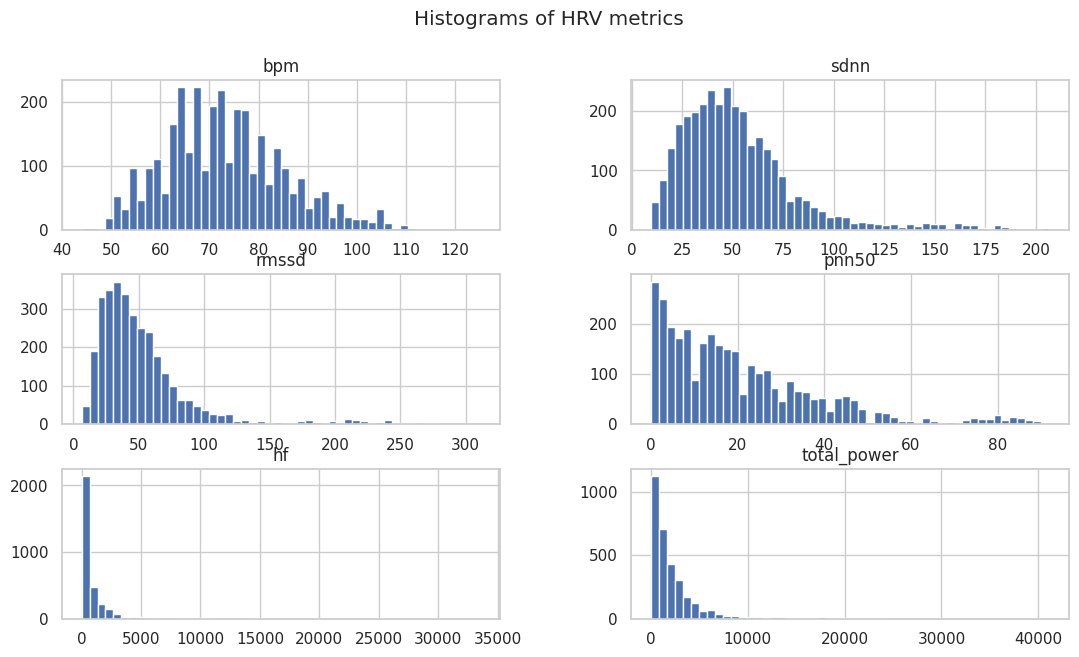

In [14]:
hrv[["bpm", "sdnn", "rmssd", "pnn50", "hf", "total_power"]].hist(bins=50, figsize=(13, 7))
plt.suptitle("Histograms of HRV metrics")
plt.show()

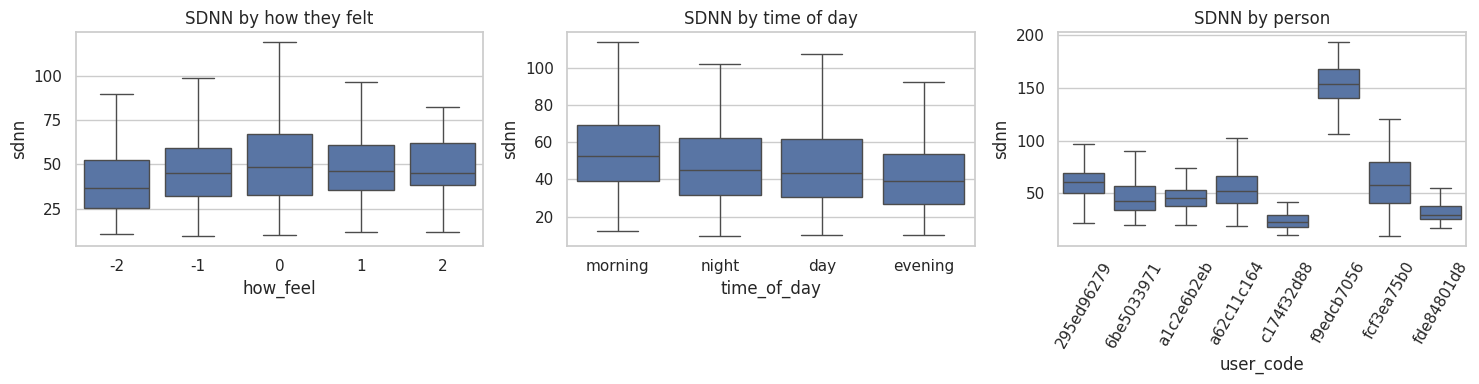

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=hrv, x="how_feel", y="sdnn", showfliers=False, ax=ax[0])
ax[0].set_title("SDNN by how they felt")

sns.boxplot(data=hrv, x="time_of_day", y="sdnn", showfliers=False, ax=ax[1])
ax[1].set_title("SDNN by time of day")

busiest = hrv.user_code.value_counts().head(8).index
sns.boxplot(data=hrv[hrv.user_code.isin(busiest)], x="user_code", y="sdnn",
            showfliers=False, ax=ax[2])
ax[2].set_title("SDNN by person")
ax[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

## Interpretation

The histograms match what the skew numbers said. `bpm`, `sdnn`, `rmssd` and `pnn50` are usable. `hf` and `total_power` are a spike at zero with a long tail, and nothing can be read off them in that state.

The boxplots by state and by time of day show small differences with a lot of overlap. Real effects, but not large ones.

The third boxplot is the important one. Plotting SDNN separately for the eight most active participants shows boxes that barely overlap. One person sits around 30 and another around 90, and both are normal for themselves. A single cutoff for "abnormal HRV" across the whole dataset would therefore be meaningless, and a standard outlier filter would mostly delete the naturally high-HRV people. This is what motivates the per-person z-score feature later on.

## Questions we are asking:
* How should the missing values be handled?
* Are the duplicate keys actually duplicates?
* Which extreme values are errors, and which are just unusual people?

In [16]:
# is how_sleep missing at random?
print("% of how_sleep missing, by time of day:")
print(hrv.groupby("time_of_day").how_sleep.apply(lambda x: x.isnull().mean() * 100).round(1))

% of how_sleep missing, by time of day:
time_of_day
day         96.9
evening    100.0
morning      1.8
night       99.6
Name: how_sleep, dtype: float64


In [17]:
# drop anything over 90% empty
drop_wear = wearables.columns[wearables.isnull().mean() > 0.9]
drop_sleep = sleep.columns[sleep.isnull().mean() > 0.9]
print("dropping from wearables:", list(drop_wear))
print("dropping from sleep:", list(drop_sleep))

wearables_clean = wearables.drop(columns=drop_wear)
sleep_clean = sleep.drop(columns=drop_sleep)

# keep the optional self-report columns but record whether they answered
hrv_clean = hrv.copy()
hrv_clean["answered_sleep_q"] = hrv.how_sleep.notnull().astype(int)
hrv_clean["used_tags"] = hrv.tags.notnull().astype(int)

dropping from wearables: ['average_spo2_value', 'body_temperature_avg', 'average_headphone_exposure', 'average_environment_exposure']
dropping from sleep: ['sleep_awake_duration', 'sleep_rem_duration', 'sleep_light_duration', 'sleep_deep_duration', 'pulse_min', 'pulse_max', 'pulse_average']


In [18]:
for name, df in [("participants", participants), ("hrv", hrv), ("wearables", wearables),
                 ("sleep", sleep), ("surveys", surveys)]:
    print(name, "exact duplicate rows:", df.duplicated().sum())

participants exact duplicate rows: 0
hrv exact duplicate rows: 0
wearables exact duplicate rows: 0
sleep exact duplicate rows: 0
surveys exact duplicate rows: 0


In [19]:
# sleep has 38 repeated user/day rows. naps?
dupes = sleep[sleep.duplicated(["user_code", "day"], keep=False)]
print(dupes.sort_values(["user_code", "day"]).head(8)[["user_code", "day", "sleep_begin", "sleep_end", "sleep_duration"]])

# a nap should be shorter than a full night, so check if the durations differ
n_durations = dupes.groupby(["user_code", "day"]).sleep_duration.nunique()
print("\ngroups where all the durations are the same:", (n_durations == 1).sum(), "out of", len(n_durations))

      user_code         day          sleep_begin            sleep_end  \
202  4985083f4d  2020-03-10  2020-03-09 23:18:09  2020-03-10 07:20:06   
203  4985083f4d  2020-03-10  2020-03-09 21:18:09  2020-03-10 05:20:06   
213  6be5033971  2020-01-04  2020-01-03 22:40:00  2020-01-04 08:20:00   
214  6be5033971  2020-01-04  2020-01-03 23:40:00  2020-01-04 09:20:00   
228  6be5033971  2020-01-18  2020-01-17 23:10:00  2020-01-18 09:50:00   
229  6be5033971  2020-01-18  2020-01-17 22:10:00  2020-01-18 08:50:00   
249  6be5033971  2020-02-07  2020-02-06 22:10:00  2020-02-07 07:05:00   
250  6be5033971  2020-02-07  2020-02-06 23:10:00  2020-02-07 08:05:00   

     sleep_duration  
202         28917.0  
203         28917.0  
213         34800.0  
214         34800.0  
228         38400.0  
229         38400.0  
249         32100.0  
250         32100.0  

groups where all the durations are the same: 36 out of 36


In [20]:
key = ["user_code", "scale", "created_at"]
same_q = surveys.groupby(key).value.nunique()
print("repeated survey keys:", surveys.duplicated(key).sum())
print("...with different answers:", (same_q > 1).sum())

# example
example = same_q[same_q > 1].index[0]
print()
print(surveys[(surveys.user_code == example[0]) & (surveys.scale == example[1]) &
              (surveys.created_at == example[2])][["scale", "value", "text"]])

repeated survey keys: 24
...with different answers: 22

       scale  value                                               text
79  S_CORONA      4     Symptoms are not characteristic of coronavirus
80  S_CORONA      1  User has some of the symptoms associated with ...


In [21]:
# same duration + same day = timezone copy, so dedupe on that. a real nap would survive.
sleep_clean = sleep_clean.drop_duplicates(["user_code", "day", "sleep_duration"])
surveys_clean = surveys.drop_duplicates(key, keep="last")

print("sleep  ", len(sleep), "->", len(sleep_clean))
print("surveys", len(surveys), "->", len(surveys_clean))

sleep   425 -> 387
surveys 2259 -> 2235


In [22]:
def pct_flagged(x, method):
    if method == "iqr":
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        flag = (x < q1 - 1.5*(q3-q1)) | (x > q3 + 1.5*(q3-q1))
    elif method == "zscore":
        flag = ((x - x.mean()) / x.std()).abs() > 3
    else:  # modified z, uses median so the outliers don't move the threshold
        mad = (x - x.median()).abs().median()
        flag = (0.6745 * (x - x.median()) / mad).abs() > 3.5
    return round(flag.mean() * 100, 2)

rows = []
for col in ["bpm", "sdnn", "rmssd", "hf"]:
    rows.append({"column": col,
                 "iqr": pct_flagged(hrv[col], "iqr"),
                 "zscore": pct_flagged(hrv[col], "zscore"),
                 "modified_z": pct_flagged(hrv[col], "mad"),
                 "skew": round(hrv[col].skew(), 2)})

pd.DataFrame(rows).set_index("column")

,iqr,zscore,modified_z,skew
column,,,,
bpm,0.77,0.28,0.09,0.48
sdnn,4.59,2.53,3.33,1.72
rmssd,6.01,3.17,4.47,2.66
hf,10.29,2.74,14.05,5.34


In [23]:
# only people with enough measurements to have a baseline
busy = hrv[hrv.groupby("user_code").sdnn.transform("size") >= 20].copy()

busy["z_all"] = (busy.sdnn - hrv.sdnn.mean()) / hrv.sdnn.std()
busy["z_self"] = busy.groupby("user_code").sdnn.transform(lambda x: (x - x.mean()) / x.std())

a = busy.z_all.abs() > 2
b = busy.z_self.abs() > 2

print("people included:", busy.user_code.nunique())
print("odd for the group, normal for them:", (a & ~b).sum())
print("normal for the group, odd for them:", (~a & b).sum())
print("both:", (a & b).sum())

people included: 30
odd for the group, normal for them: 101
normal for the group, odd for them: 82
both: 18


## Interpretation, and the reasoning behind each choice

### Missing values

The obvious explanation for `how_sleep` being 55% missing is that people skip it. The breakdown by time of day says otherwise: 1.8% missing in the morning and 97% to 100% at every other time. The app only asks "how did you sleep?" after a morning measurement. So this is not user behaviour at all, it is how the app works, and it is fully predictable from a column already in the table.

Columns over 90% empty, meaning SpO2, temperature and the sleep stages, were dropped. Imputing 3,000 blood oxygen values from 40 real ones is not filling a gap, it is inventing data, and these would be the most important values in the file if they were real.

`how_sleep` and `tags` were kept as they are, with an extra column recording whether an answer exists. Self-reports should not be imputed, and whether someone bothered to answer is itself a small piece of information.

`symptoms_onset` was left null where it is missing. Filling it in would mean inventing the illness timeline that half the analysis depends on.

The wearable step and pulse columns were kept but not forward-filled. Carrying yesterday's step count forward would create activity on a day the person was not wearing the device, and afterwards that value would be indistinguishable from a real one.

### Duplicates

There are no exactly duplicated rows in any table, so `drop_duplicates()` on its own does nothing here. The real problem is repeated keys.

Sleep has 36 repeated user and day pairs. The natural reading is naps, and fragmented sleep would be worth keeping for someone who is ill. Checking the durations says otherwise. A nap should be shorter than a full night, but all 36 groups have identical durations, with start times shifted by whole hours. These are the same sleep session recorded at different timezone offsets, most likely a sync issue. Deduplicating on user, day and duration removes the copies while leaving a genuine nap, which would have a different length, intact. Seven of the ten people with sleep data are affected, so keeping the extra rows would have inflated their sleep totals two to four times over.

Surveys have 24 repeated keys, and 22 of them give different answers to the same question on the same day. The last answer was kept, on the reading that a second answer is a correction. Averaging would be wrong on a scale where 2 means "very mild" and 3 means "mild", since the average is not a category anyone chose.

### Outliers

The three methods disagree a lot on the skewed columns. On `hf` the z-score flags 2.7% and the modified z-score flags 14.1%. The z-score is built from the mean and standard deviation, and the outliers inflate both, so they end up raising the threshold that is meant to catch them. The modified z-score uses the median, which does not move. So MAD was used for the skewed columns and IQR for the symmetric ones.

The bigger question is what "outlier" means here at all. Among the people with enough data to check, 101 measurements are extreme for the cohort but perfectly normal for that individual, and 82 are the opposite. Only 18 show up both ways. Since the point of this data is spotting when someone's physiology changes, the second group is the one that matters, and a standard filter would delete the first group for no reason.

Values that cannot be real, like the 250 cm height and the 1967 onset date, were set to null. Values that are merely unusual were kept. Nothing was winsorized or clipped. With 3,245 rows, keeping the tails is worth more than tidier histograms.

## Questions we are asking:
* Does anything need transforming or rescaling?
* What has to be converted before the data is internally consistent?

In [24]:
# dates
hrv_clean["date"] = pd.to_datetime(hrv_clean.measurement_datetime).dt.normalize()

participants_clean = participants.copy()
participants_clean["onset"] = onset.mask((onset < "2019-12-01") | (onset > "2020-06-30"))
print("usable onset dates:", participants_clean.onset.notnull().sum())

# units
hrv_clean["mxdmn_ms"] = hrv_clean.mxdmn * 1000
sleep_clean["sleep_hours"] = sleep_clean.sleep_duration / 3600
print("mxdmn_ms median:", hrv_clean.mxdmn_ms.median(), " sdnn median:", round(hrv_clean.sdnn.median(), 1))
print("sleep hours median:", round(sleep_clean.sleep_hours.median(), 2))

# impossible heights -> null, but keep the row
participants_clean.loc[participants_clean.height > 220, "height"] = np.nan
participants_clean.loc[participants_clean.height < 130, "height"] = np.nan

usable onset dates: 134
mxdmn_ms median: 160.0  sdnn median: 46.9
sleep hours median: 7.23


             before  after
lf             3.80  -0.24
hf             5.34   0.24
vlf            6.05  -0.32
total_power    3.79  -0.02


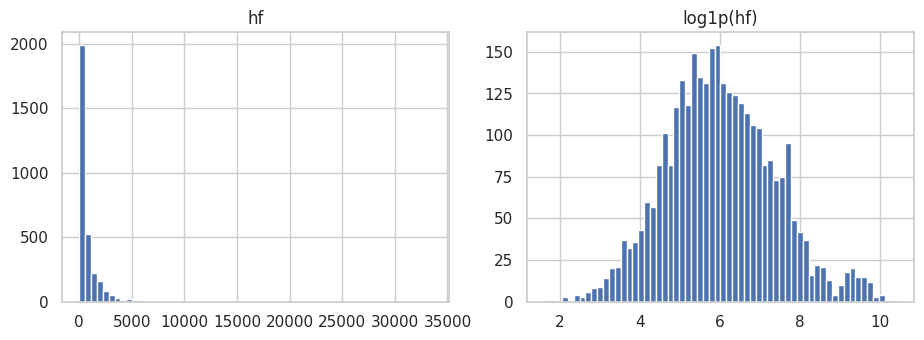

In [25]:
for col in ["lf", "hf", "vlf", "total_power"]:
    hrv_clean["log_" + col] = np.log1p(hrv_clean[col])

print(pd.DataFrame({
    "before": [hrv_clean[c].skew() for c in ["lf", "hf", "vlf", "total_power"]],
    "after": [hrv_clean["log_" + c].skew() for c in ["lf", "hf", "vlf", "total_power"]],
}, index=["lf", "hf", "vlf", "total_power"]).round(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(hrv_clean.hf, bins=60)
ax[0].set_title("hf")
ax[1].hist(hrv_clean.log_hf, bins=60)
ax[1].set_title("log1p(hf)")
plt.show()

## Interpretation

Converting the dates is the obvious step. Nothing downstream works without it.

The unit fixes matter more than they look. Multiplying `mxdmn` by 1000 puts every time-based column in the same unit, and the sanity check now passes: the median range is 160 and the median standard deviation is 47, so the range is larger, which it has to be. Before the fix the range read as 0.16 and looked like a rounding error. Dividing `sleep_duration` by 3600 gives a median of 7.2 hours, which is a believable night.

This is worth fixing rather than just noting. If one column is scaled 1000 times differently from the rest, anything using distances or regularization will either be dominated by it or ignore it, and nothing will warn you.

The impossible heights were set to null while keeping the row. The rest of that person's record is fine and there is no reason to lose it.

The log transform works well. `hf` goes from a skew of 5.3 to 0.2 and the histogram becomes roughly bell-shaped. `log1p` was used instead of `log` because some power values get close to zero. The original columns were kept as well.

## Questions we are asking:
* Are there new features that can be derived from the existing ones?
* Can domain knowledge produce something better than the raw columns?

### Feature 1: `days_since_onset`

Calendar dates are not very useful here because everyone got sick at a different time. Comparing March 15th across two participants might mean comparing someone mid-illness to someone healthy. Instead, each measurement gets the number of days between it and that person's own `symptoms_onset`. Negative means before symptoms started, 0 is the onset day, positive is after.

This only works on the cleaned onset dates. The code below shows what the feature looks like if the raw column with the 13 birthdays is used instead.

### Feature 2: `stress_index`

Rather than inventing a ratio, this uses the Baevsky Stress Index, a formula from the HRV literature that happens to use three columns this dataset has:

$$\text{SI} = \frac{AMo}{2 \cdot Mo \cdot MxDMn}$$

Mo is the most common interval and MxDMn is the range, both in seconds. The idea is that when the body is under strain the intervals bunch tightly around one value, so a tall narrow peak divided by a small range gives a high number.

This is where the unit checking earlier pays off. The docs say `mode` is in milliseconds and it is not. Dividing by 1000 as the docs imply would make every value 1000 times too big, and the rank order would be unchanged, so no correlation and no model score would look wrong. The only way to notice is to compare against published reference ranges.

### Feature 3: `sdnn_z`

This follows directly from the participant boxplot. Instead of comparing someone's SDNN to everyone else's, compare it to their own average. A value of −2 then means two standard deviations below normal for that specific person, which is the useful question.

In [26]:
df = hrv_clean.merge(participants_clean[["user_code", "onset", "height", "weight", "age_range"]],
                     on="user_code", how="left")

df["days_since_onset"] = (df.date - df.onset).dt.days

# what it would have looked like without cleaning the onset dates
raw_onset = dict(zip(participants.user_code, onset))
raw_days = (df.date - df.user_code.map(raw_onset)).dt.days
print(pd.DataFrame({"raw": raw_days.describe(), "cleaned": df.days_since_onset.describe()}).round(1))

print("\nmeasurements with a usable onset:", df.days_since_onset.notnull().sum(),
      "from", df[df.days_since_onset.notnull()].user_code.nunique(), "people")

df["phase"] = pd.cut(df.days_since_onset, [-np.inf, -8, -1, 3, 14, np.inf],
                     labels=["baseline", "pre-symptomatic", "acute", "symptomatic", "recovery"])

           raw  cleaned
count   2816.0   2685.0
mean     517.5      9.8
std     2705.2     46.8
min     -726.0   -128.0
25%       -6.0     -9.0
50%       22.0     20.0
75%       44.0     40.0
max    19465.0     97.0

measurements with a usable onset: 2685 from 134 people


In [27]:
# Baevsky stress index. mode is already in seconds (see the units check above), mxdmn too.
df["stress_index"] = df.amo / (2 * df["mode"] * df.mxdmn)

print(df.stress_index.describe().round(1))
print("\npublished resting range is roughly 50-150")

# what it would be if I'd followed the docs and treated mode as ms
if_docs_were_right = df.amo / (2 * (df["mode"] / 1000) * df.mxdmn)
print("\nmedian if I'd divided by 1000:", round(if_docs_were_right.median()))
print("correlation between the two versions:",
      round(df.stress_index.corr(if_docs_were_right, method="spearman"), 4))
print("correlation with sdnn:", round(df.stress_index.corr(df.sdnn, method="spearman"), 3))

count    3245.0
mean      266.9
std       304.8
min         9.0
25%        86.6
50%       161.3
75%       317.2
max      2586.7
Name: stress_index, dtype: float64

published resting range is roughly 50-150

median if I'd divided by 1000: 161290
correlation between the two versions: 1.0
correlation with sdnn: -0.918


In [28]:
# z-score against the person's own measurements, not the whole group
n_per_person = df.groupby("user_code").sdnn.transform("size")

for col in ["sdnn", "rmssd"]:
    z = df.groupby("user_code")[col].transform(lambda x: (x - x.mean()) / x.std())
    df[col + "_z"] = z.where(n_per_person >= 5)

df["bmi"] = df.weight / (df.height / 100) ** 2

print(df[["sdnn", "sdnn_z", "rmssd_z", "stress_index", "bmi"]].describe().round(2))

          sdnn   sdnn_z  rmssd_z  stress_index      bmi
count  3245.00  3071.00  3071.00       3245.00  3235.00
mean     52.49     0.00    -0.00        266.94    27.77
std      29.37     0.99     0.99        304.81     7.48
min       9.52    -2.88    -2.99          9.00    16.29
25%      32.58    -0.70    -0.69         86.58    22.30
50%      46.92    -0.14    -0.17        161.29    26.81
75%      64.41     0.58     0.51        317.20    31.25
max     206.63     6.02     5.78       2586.67    54.28


                 sdnn_z  rmssd_z     n  people
phase                                         
baseline          0.181    0.301   107      10
pre-symptomatic  -0.148   -0.217    37       8
acute            -0.599   -0.526    63      26
symptomatic      -0.017    0.008   352      69
recovery          0.033    0.003  1007      84


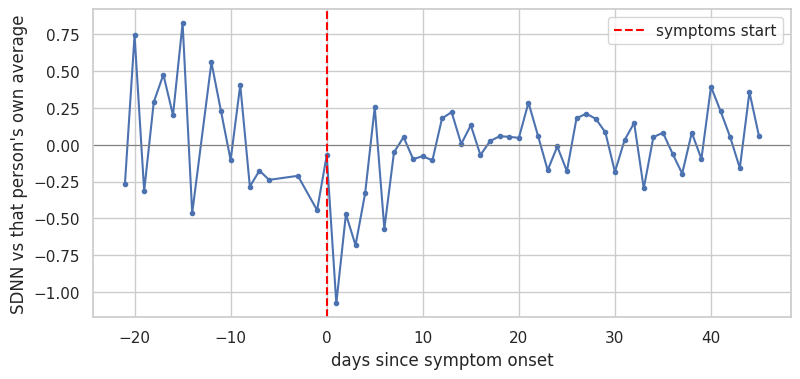

In [29]:
window = df[df.days_since_onset.between(-21, 45)]

print(window.groupby("phase", observed=True).agg(
    sdnn_z=("sdnn_z", "mean"),
    rmssd_z=("rmssd_z", "mean"),
    n=("sdnn", "size"),
    people=("user_code", "nunique")).round(3))

by_day = window.groupby("days_since_onset").agg(z=("sdnn_z", "mean"), n=("sdnn", "size"))
by_day = by_day[by_day.n >= 5]

plt.figure(figsize=(9, 4))
plt.plot(by_day.index, by_day.z, marker="o", markersize=3)
plt.axhline(0, color="grey", linewidth=0.8)
plt.axvline(0, color="red", linestyle="--", label="symptoms start")
plt.xlabel("days since symptom onset")
plt.ylabel("SDNN vs that person's own average")
plt.legend()
plt.show()

## Interpretation

Cleaning the onset dates was worth doing. On the raw dates the mean comes out at 518 days with a maximum of 19,465 because of the birthdays. Cleaned, the median is 20 days, which is sensible. The feature covers 83% of measurements across 134 of the 185 people.

The stress index behaves the way the theory says it should. It correlates with SDNN at −0.92 in the opposite direction, which is a good sign the formula was implemented correctly. The values run above the published 50 to 150 range, probably because these are people who thought they were sick, measuring at home in whatever position, rather than lying down in a lab. It is more useful for comparing a person against themselves than as a threshold. At −0.92 it is also close to a restatement of SDNN, so both should not go into the same linear model.

The onset plot does show something. HRV drops to about 0.6 standard deviations below each person's own average in the first few days of symptoms and then recovers. That is what an acute infection would be expected to do.

It should not be read as a result, though. The acute window is 63 measurements from 26 people and the pre-symptomatic window is 37 from 8, so the most interesting part of the chart has the least data behind it. The people contributing at day −10 are not the same people contributing at day +30, so part of the line could be the changing mix rather than anyone's physiology. And the whole x-axis rests on `symptoms_onset`, which is already known to be the least reliable field in the dataset.

# Data quality assessment

**Profiling.** Every column in every table was checked for type, missingness, unique counts and distribution. 185 participants, 3,245 HRV measurements, no constant columns and nothing completely empty.

**Completeness.** Poor. Eleven columns are over 90% missing, the worst being SpO2 at 98.7% and `sleep_rem_duration` with seven real values. Coverage runs from 100% of participants for HRV down to 5% for sleep. The median person has four measurements and the maximum is 405. Most of the missingness comes from what device someone owned, so it is not random. The exception is `how_sleep`, which is missing because the app only asks after morning measurements, making it predictable from `time_of_day`.

**Accuracy.** Split. The computed columns are reliable. `meanrr` and `sdnn` rebuild from the raw intervals to within float rounding and `total_power` equals the sum of its three bands exactly. The typed-in columns are not: 13 of 147 onset dates are birthdays or year typos, and all of them pass a format check, so only a check against the study window finds them. There are also two impossible heights.

**Consistency.** Poor. The documentation gets two units wrong, `sleep_duration` in seconds rather than hours and `mode` in seconds rather than milliseconds. There are mixed units inside the HRV table and three different date formats across the files. The categorical encodings are consistent, and the −2 to +2 scales use the same values everywhere with no stray 99s or −999s.

**Integrity.** Good. No user codes appear that are missing from `participants`, the primary key is not duplicated, every survey code resolves against the lookup, and every table's dates fall inside the collection window. The repeated keys in `sleep` and `surveys` turned out to be timezone copies and conflicting re-answers rather than integrity failures.

**Lineage and provenance.** The chain runs from the Welltory app, to an anonymized research export, to the public GitHub repo, to the downloaded CSVs, to this notebook. The CSV files were not edited. Inside the notebook the raw DataFrames are left untouched and the cleaned versions get a `_clean` suffix, so any value can be traced back to what it was before. The one gap that cannot be closed is that Welltory does not document what signal processing happened between the raw camera signal and the `rr_data` in the file, so everything here sits downstream of a step that is not visible.

**Overall.** Usable for exploration and for following individual people over time. Not usable for saying anything about a population, and not usable for saying anything about COVID specifically, since nobody in the dataset has a confirmed diagnosis.

# Interpretation for Machine Learning

**Size.** 3,245 measurements from 185 people is not much. Simple models with regularization would be appropriate, not anything deep.

**Splitting.** This is the decision that would break things if handled badly. The split has to be by `user_code`, not by row. A random row split puts the same person in both train and test, and because HRV is so person-specific the model can learn to recognize individuals and score well for the wrong reason.

**Data types.** Dates need converting, `age_range` and `gender` need encoding, and `rr_data` is a raw signal string rather than a feature.

**Missing values.** Imputation is not appropriate here. Indicator columns plus a model that handles nulls natively, such as gradient boosting, would be better.

**Distributions.** The `log_` versions of the frequency columns should be used. The raw ones are unusable for anything assuming normality.

**Redundancy.** The HRV metrics correlate up to 1.0 with each other. Three or four should be kept, or PCA applied.

**Person-specific variance.** The `_z` features are more appropriate than the raw values, since the question is about change within a person. One caveat: the version built here uses each person's whole series, including measurements taken after the one being scored. That is fine for describing what happened, but a prediction model would need a version that only looks backwards.

**Weighting.** Ten users account for 54% of the rows, so either weight by participant or aggregate to one row per person first.

**Expectations.** 134 people have a usable illness timeline and far fewer have enough measurements to show a trend. Intervals would be more honest than point estimates, and these results should not be expected to replicate.